# Лабораторная работа №6  
# Vision-Language Models (VLM)

---

**Выполнил(а):** студент(ка) группы ______  
**ФИО:** _______________________________  
**Дата:** _______________________________

---

## 1. Цель работы

- Изучить архитектуру CLIP и контрастивное обучение
- Понять принцип zero-shot классификации изображений
- Научиться выполнять поиск изображений по текстовому запросу
- Освоить работу с эмбеддингами изображений и текста
- Научиться создавать собственные классификаторы изображений

---

## 2. Теоретические сведения

### 2.1. Vision-Language Models

**VLM (Vision-Language Model)** — модель, которая связывает визуальную и текстовую информацию в едином пространстве представлений.

**Ключевая идея:**
- Изображения и тексты кодируются в векторы одинаковой размерности
- Семантически связанные пары (изображение, текст) имеют близкие векторы
- Это позволяет выполнять кросс-модальный поиск

### 2.2. Архитектура CLIP

**CLIP (Contrastive Language-Image Pre-training)** — модель от OpenAI.

**Обучение:**
- Использует 400 миллионов пар (изображение, подпись)
- Контрастивная функция потерь максимизирует сходство правильных пар
- Минимизирует сходство неправильных пар

### 2.3. Zero-Shot Классификация

**Zero-Shot** — классификация без дополнительного обучения.

**Алгоритм:**
1. Создаём текстовые описания для каждого класса
2. Кодируем тексты в эмбеддинги
3. Кодируем изображение в эмбеддинг
4. Находим наиболее близкий текстовый эмбеддинг
5. Возвращаем соответствующий класс

### 2.4. Варианты CLIP

| Модель | Размер | Vision Encoder | Точность | Скорость |
|--------|--------|---------------|----------|----------|
| `ViT-B/32` | ~150M | Vision Transformer | 92.2% | Быстро |
| `ViT-B/16` | ~150M | Vision Transformer | 93.5% | Средне |
| `ViT-L/14` | ~430M | Vision Transformer | 95.1% | Медленно |
| `RN50` | ~100M | ResNet-50 | 90.5% | Очень быстро |

---

## 3. Задание

### 3.1. Базовый уровень (обязательно)

1. Загрузите модель CLIP из Hugging Face
2. Подготовьте набор изображений (20+ штук)
3. Реализуйте zero-shot классификацию с 5+ категориями
4. Оцените точность классификации
5. Визуализируйте результаты

### 3.2. Продвинутый уровень (дополнительно)

- Сравните разные версии CLIP (ViT-B/32, ViT-L/14, RN50)
- Реализуйте поиск изображений по текстовому запросу
- Постройте матрицу сходства текст-изображение

### 3.3. Индивидуальное задание

Создайте классификатор для своей предметной области:
- **Вариант A:** Классификация типов документов
- **Вариант B:** Распознавание типов помещений/интерьеров
- **Вариант C:** Классификация продуктов питания
- **Вариант D:** Определение пород животных/видов растений

Подготовьте 20+ изображений и протестируйте классификатор.

---

## 4. Ход работы

### 4.1. Подготовка окружения

In [1]:
# Проверка доступности GPU
import torch

print(f"GPU доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU устройство: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU не доступен. Работа возможна на CPU, но медленнее.")

GPU доступен: True
GPU устройство: Tesla T4


In [2]:
# Установка зависимостей
!pip install transformers torch torchvision pillow clip-openai -q

# Проверка версий
import transformers
import torch
import clip

print(f"Transformers: {transformers.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CLIP: OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
Transformers: 5.0.0
PyTorch: 2.10.0+cu128
CLIP: OK


In [3]:
# Импорт библиотек
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Настройка устройства
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


### 4.2. Загрузка модели CLIP

Используем официальную реализацию OpenAI.

In [4]:
# Доступные модели CLIP
available_models = clip.available_models()
print("Доступные модели CLIP:")
for model_name in available_models:
    print(f"  - {model_name}")

Доступные модели CLIP:
  - RN50
  - RN101
  - RN50x4
  - RN50x16
  - RN50x64
  - ViT-B/32
  - ViT-B/16
  - ViT-L/14
  - ViT-L/14@336px


In [5]:
# Загрузка модели
model_name = "ViT-B/32"  # Баланс между точностью и скоростью

print(f"Загрузка модели: {model_name}")
model, preprocess = clip.load(model_name, device=device)

print("Модель загружена")
print(f"Устройство: {device}")

Загрузка модели: ViT-B/32


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 308MiB/s]


Модель загружена
Устройство: cuda


### 4.3. Подготовка тестовых изображений

Загрузим изображения из разных категорий.

In [6]:
# Функция загрузки изображения
def load_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Тестовые изображения по категориям
test_images = {
    "кошка": [
        "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
        "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=400",
        "https://images.unsplash.com/photo-1495360019602-e0019216adfe?w=400"
    ],
    "собака": [
        "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=400",
        "https://images.unsplash.com/photo-1587300003388-59208cc962cb?w=400",
        "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400"
    ],
    "автомобиль": [
        "https://images.unsplash.com/photo-1568605117036-5fe5e7bab0b7?w=400",
        "https://images.unsplash.com/photo-1583121274602-3e2820c69888?w=400",
        "https://images.unsplash.com/photo-1552519507-cf0d5a6e5d0d?w=400"
    ],
    "еда": [
        "https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=400",
        "https://images.unsplash.com/photo-1482049016688-2d3e1b311543?w=400",
        "https://images.unsplash.com/photo-1476224203421-9ac39bcb3327?w=400"
    ],
    "природа": [
        "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400",
        "https://images.unsplash.com/photo-1472214103451-9374bd1c798e?w=400",
        "https://images.unsplash.com/photo-1441974231531-c6227db76b6e?w=400"
    ]
}

# Загрузка всех изображений
print("Загрузка изображений...")
images_data = []
labels_true = []

for category, urls in test_images.items():
    for url in urls:
        try:
            img = load_image(url)
            images_data.append(img)
            labels_true.append(category)
            print(f"  ✓ {category}")
        except Exception as e:
            print(f"  ✗ Ошибка загрузки: {e}")

print(f"\nЗагружено изображений: {len(images_data)}")

Загрузка изображений...
  ✓ кошка
  ✓ кошка
  ✗ Ошибка загрузки: cannot identify image file <_io.BytesIO object at 0x7832836e7510>
  ✓ собака
  ✓ собака
  ✓ собака
  ✓ автомобиль
  ✓ автомобиль
  ✗ Ошибка загрузки: cannot identify image file <_io.BytesIO object at 0x78328352c6d0>
  ✓ еда
  ✓ еда
  ✓ еда
  ✓ природа
  ✓ природа
  ✓ природа

Загружено изображений: 13


### 4.4. Zero-Shot Классификация

Реализуем классификацию без обучения.

In [7]:
# Текстовые шаблоны для классов
classes = ["кошка", "собака", "автомобиль", "еда", "природа"]

# Создаём текстовые промпты для каждого класса
templates = [
    "Это фото {}",
    "Фотография {}",
    "Изображение {}",
    "На фото изображена {}",
    "{} на снимке"
]

def create_text_embeddings(classes, model, templates=None):
    if templates is None:
        templates = ["Это фото {}"]
    
    all_embeddings = []
    
    for cls in classes:
        cls_texts = [template.format(cls) for template in templates]
        text_tokens = clip.tokenize(cls_texts).to(device)
        
        with torch.no_grad():
            text_features = model.encode_text(text_tokens)
        
        cls_embedding = text_features.mean(dim=0, keepdim=True)
        cls_embedding = cls_embedding / cls_embedding.norm(dim=-1, keepdim=True)
        all_embeddings.append(cls_embedding)
    
    text_embeddings = torch.cat(all_embeddings, dim=0)
    return text_embeddings

print("Создание текстовых эмбеддингов...")
text_embeddings = create_text_embeddings(classes, model, templates)
print(f"Текстовые эмбеддинги созданы: {text_embeddings.shape}")

Создание текстовых эмбеддингов...
Текстовые эмбеддинги созданы: torch.Size([5, 512])


In [8]:
# Функция классификации изображения
def classify_image(image, model, preprocess, text_embeddings, classes):
    image_input = preprocess(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    
    with torch.no_grad():
        similarities = (image_features @ text_embeddings.T).squeeze()
    
    probabilities = torch.softmax(similarities * 10, dim=0)
    predicted_idx = similarities.argmax().item()
    predicted_class = classes[predicted_idx]
    
    return predicted_class, probabilities.cpu().numpy()

print("Функция классификации готова")

Функция классификации готова


In [9]:
# Классификация всех изображений
print("="*60)
print("ZERO-SHOT КЛАССИФИКАЦИЯ ИЗОБРАЖЕНИЙ")
print("="*60)

predictions = []
all_probabilities = []

for i, img in enumerate(images_data):
    pred_class, probs = classify_image(img, model, preprocess, text_embeddings, classes)
    predictions.append(pred_class)
    all_probabilities.append(probs)
    
    true_label = labels_true[i]
    status = "✓" if pred_class == true_label else "✗"
    
    print(f"\n{status} Изображение #{i+1}")
    print(f"  Истинный класс: {true_label}")
    print(f"  Предсказание: {pred_class}")
    print(f"  Вероятности: {[f'{p:.2f}' for p in probs]}")

ZERO-SHOT КЛАССИФИКАЦИЯ ИЗОБРАЖЕНИЙ

✓ Изображение #1
  Истинный класс: кошка
  Предсказание: кошка
  Вероятности: ['0.25', '0.19', '0.19', '0.19', '0.18']

✓ Изображение #2
  Истинный класс: кошка
  Предсказание: кошка
  Вероятности: ['0.26', '0.19', '0.19', '0.17', '0.19']

✗ Изображение #3
  Истинный класс: собака
  Предсказание: кошка
  Вероятности: ['0.23', '0.20', '0.19', '0.19', '0.20']

✗ Изображение #4
  Истинный класс: собака
  Предсказание: кошка
  Вероятности: ['0.23', '0.19', '0.19', '0.18', '0.20']

✗ Изображение #5
  Истинный класс: собака
  Предсказание: кошка
  Вероятности: ['0.24', '0.20', '0.19', '0.18', '0.19']

✓ Изображение #6
  Истинный класс: автомобиль
  Предсказание: автомобиль
  Вероятности: ['0.18', '0.19', '0.24', '0.19', '0.20']

✓ Изображение #7
  Истинный класс: автомобиль
  Предсказание: автомобиль
  Вероятности: ['0.19', '0.18', '0.24', '0.18', '0.21']

✗ Изображение #8
  Истинный класс: еда
  Предсказание: кошка
  Вероятности: ['0.22', '0.20', '0.20',

### 4.5. Оценка качества классификации

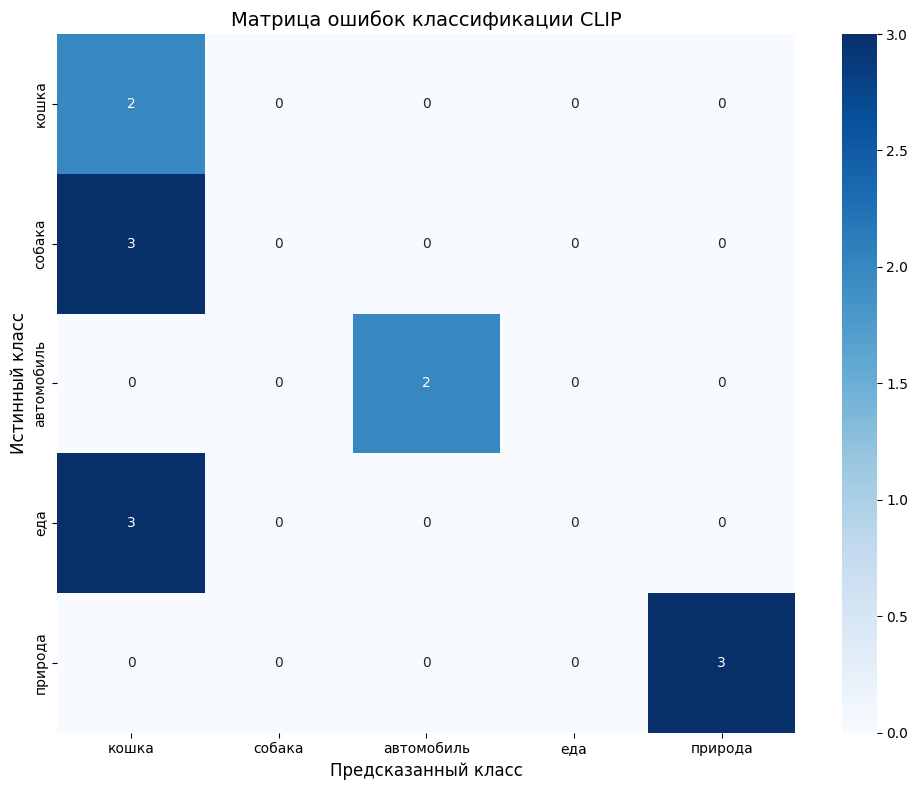


ОТЧЁТ О КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

       кошка       1.00      1.00      1.00         2
      собака       0.00      0.00      0.00         3
  автомобиль       0.25      1.00      0.40         2
         еда       1.00      1.00      1.00         3
     природа       0.00      0.00      0.00         3

    accuracy                           0.54        13
   macro avg       0.45      0.60      0.48        13
weighted avg       0.42      0.54      0.45        13


Общая точность: 53.85%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Матрица ошибок
cm = confusion_matrix(labels_true, predictions, labels=classes)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок классификации CLIP', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

# Отчёт о классификации
print("\n" + "="*60)
print("ОТЧЁТ О КЛАССИФИКАЦИИ")
print("="*60)
print(classification_report(labels_true, predictions, target_names=classes))

# Общая точность
accuracy = sum(p == t for p, t in zip(predictions, labels_true)) / len(labels_true)
print(f"\nОбщая точность: {accuracy:.2%}")

### 4.6. Поиск изображений по тексту

In [11]:
# Функция поиска изображений
def search_images(query, images, model, preprocess, top_k=3):
    text_tokens = clip.tokenize([query]).to(device)
    
    with torch.no_grad():
        query_embedding = model.encode_text(text_tokens)
        query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)
    
    image_embeddings = []
    for img in images:
        img_input = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            img_embedding = model.encode_image(img_input)
            img_embedding = img_embedding / img_embedding.norm(dim=-1, keepdim=True)
        image_embeddings.append(img_embedding)
    
    image_embeddings = torch.cat(image_embeddings, dim=0)
    
    similarities = (query_embedding @ image_embeddings.T).squeeze()
    top_indices = similarities.argsort(descending=True)[:top_k]
    
    return top_indices.cpu().numpy(), similarities.cpu().numpy()

print("Функция поиска готова")

Функция поиска готова


In [12]:
# Тестирование поиска
search_queries = [
    "пушистый домашний питомец",
    "быстрое транспортное средство",
    "вкусное блюдо на обед",
    "красивый горный пейзаж",
    "животное с хвостом"
]

print("="*60)
print("ПОИСК ИЗОБРАЖЕНИЙ ПО ТЕКСТУ")
print("="*60)

for query in search_queries:
    print(f"\n🔍 Запрос: '{query}'")
    print("-" * 60)
    
    top_indices, similarities = search_images(query, images_data, model, preprocess, top_k=3)
    
    for rank, idx in enumerate(top_indices, 1):
        print(f"  #{rank}: Изображение {idx+1} (сходство: {similarities[idx]:.4f})")
        print(f"      Истинный класс: {labels_true[idx]}")

ПОИСК ИЗОБРАЖЕНИЙ ПО ТЕКСТУ

🔍 Запрос: 'пушистый домашний питомец'
------------------------------------------------------------
  #1: Изображение 3 (сходство: 0.2070)
      Истинный класс: собака
  #2: Изображение 1 (сходство: 0.2057)
      Истинный класс: кошка
  #3: Изображение 11 (сходство: 0.1991)
      Истинный класс: природа

🔍 Запрос: 'быстрое транспортное средство'
------------------------------------------------------------
  #1: Изображение 1 (сходство: 0.2068)
      Истинный класс: кошка
  #2: Изображение 2 (сходство: 0.2054)
      Истинный класс: кошка
  #3: Изображение 12 (сходство: 0.2015)
      Истинный класс: природа

🔍 Запрос: 'вкусное блюдо на обед'
------------------------------------------------------------
  #1: Изображение 8 (сходство: 0.2400)
      Истинный класс: еда
  #2: Изображение 9 (сходство: 0.2313)
      Истинный класс: еда
  #3: Изображение 2 (сходство: 0.2047)
      Истинный класс: кошка

🔍 Запрос: 'красивый горный пейзаж'
------------------------------

### 4.7. Матрица сходства текст-изображение

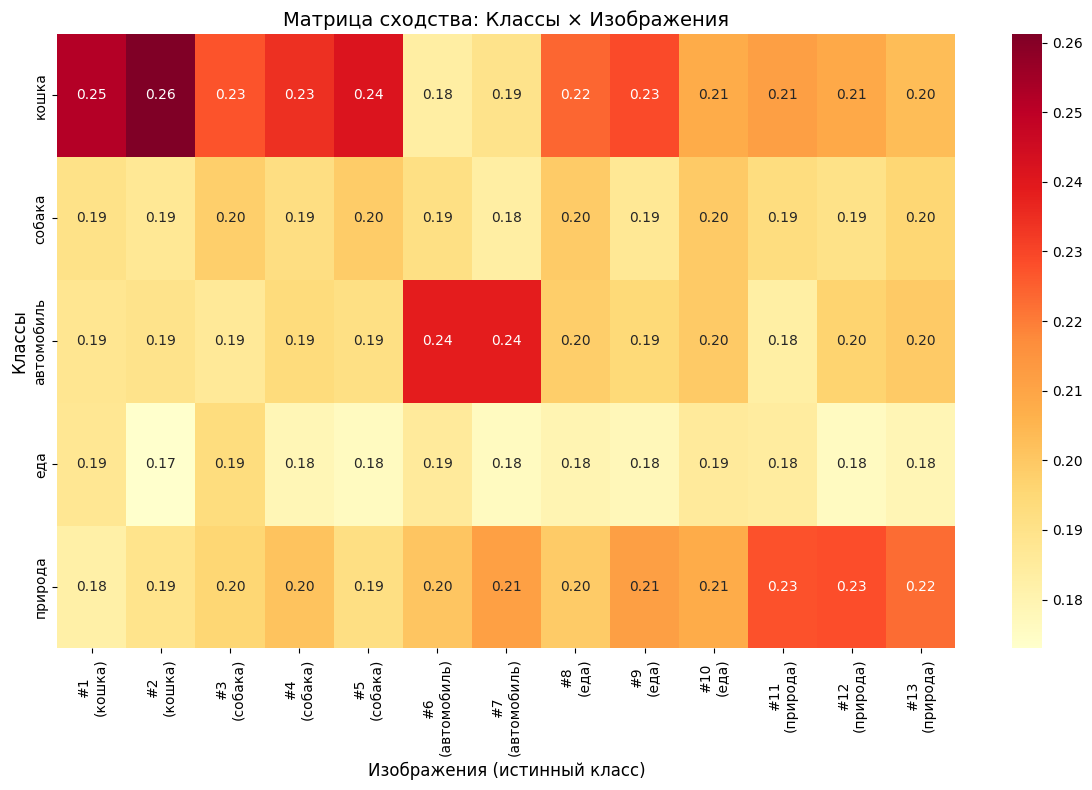

In [13]:
# Построение матрицы сходства
similarity_matrix = np.zeros((len(classes), len(images_data)))

for i, cls in enumerate(classes):
    for j, img in enumerate(images_data):
        _, probs = classify_image(img, model, preprocess, text_embeddings, classes)
        similarity_matrix[i, j] = probs[i]

# Визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            yticklabels=classes,
            xticklabels=[f"#{i+1}\n({l})" for i, l in enumerate(labels_true)])
plt.title('Матрица сходства: Классы × Изображения', fontsize=14)
plt.xlabel('Изображения (истинный класс)', fontsize=12)
plt.ylabel('Классы', fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Контрольные вопросы

**Ответы записывайте в эту ячейку (режим Markdown):**

1. **В чём заключается контрастивное обучение в CLIP?**
   > Ваш ответ...

2. **Как работает zero-shot классификация и почему она возможна?**
   > Ваш ответ...

3. **Какие преимущества у CLIP перед традиционными моделями классификации?**
   > Ваш ответ...

4. **Как размер модели влияет на точность и скорость работы?**
   > Ваш ответ...

5. **Какие практические применения есть у кросс-модального поиска?**
   > Ваш ответ...

## 6. Полезные ресурсы

- 📚 [CLIP Paper](https://arxiv.org/abs/2103.00020) — оригинальная статья OpenAI
- 📖 [OpenAI CLIP Blog](https://openai.com/blog/clip/) — описание проекта
- 🔧 [CLIP GitHub](https://github.com/openai/CLIP) — официальная реализация
- 🎥 [CLIP Explained](https://www.youtube.com/watch?v=Hbl5FZ8xGxE) — видео-объяснение
- 📊 [Hugging Face CLIP](https://huggingface.co/docs/transformers/model_doc/clip) — документация

---

> **Примечание:** Все лабораторные работы выполняются в Google Colab с использованием бесплатных ресурсов. Сохраняйте копию ноутбука в своём Google Drive через `File → Save a copy in Drive`.